# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberta a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">

<b>Comentário geral:</b> <a class="tocSkip"></a>

Yasmin, parabéns pela entrega! 👏  
Seu projeto está muito bem feito: o código é limpo, organizado e os comentários mostram que você realmente entende o que está fazendo.

Adorei os gráficos!! Legibilidade muito boa. Tudo fluiu de forma clara e objetiva, sem perder a atenção aos detalhes.

Está aprovado! Continue nesse caminho, você está mandando muito bem. 🚀

</div>

In [46]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats


In [47]:
# Configurações visuais
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Carregamento dos datasets
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders     = pd.read_csv('/datasets/orders_us.csv', parse_dates=['date'])
visits     = pd.read_csv('/datasets/visits_us.csv', parse_dates=['date'])


print('hypotheses shape:', hypotheses.shape)
print('orders shape:    ', orders.shape)
print('visits shape:    ', visits.shape)
print()
print('Colunas hypotheses:', hypotheses.columns.tolist())
print('Colunas orders:    ', orders.columns.tolist())
print('Colunas visits:    ', visits.columns.tolist())


hypotheses shape: (9, 5)
orders shape:     (1197, 5)
visits shape:     (62, 3)

Colunas hypotheses: ['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort']
Colunas orders:     ['transactionId', 'visitorId', 'date', 'revenue', 'group']
Colunas visits:     ['date', 'group', 'visits']


In [48]:
#Inspeção inicial dos dados
display(hypotheses.head())
display(hypotheses.info())

print('\n=== ORDERS ===')
display(orders.head())
display(orders.info())

print('\n=== VISITS ===')
display(visits.head())
display(visits.info())

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


None


=== ORDERS ===


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


...

None


=== VISITS ===


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


None

In [49]:
# Verificar duplicatas
print('Duplicatas em orders:', orders.duplicated().sum())
print('Duplicatas em visits:', visits.duplicated().sum())

# Verificar valores nulos
print('\nNulos em orders:')
print(orders.isnull().sum())
print('\nNulos em visits:')
print(visits.isnull().sum())



Duplicatas em orders: 0
Duplicatas em visits: 0

Nulos em orders:
transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64

Nulos em visits:
date      0
group     0
visits    0
dtype: int64


In [50]:
# Identificar usuários que aparecem em AMBOS os grupos (contaminação do teste)
users_A    = set(orders[orders['group'] == 'A']['visitorId'])
users_B    = set(orders[orders['group'] == 'B']['visitorId'])
users_both = users_A & users_B

print(f'Usuários somente no grupo A: {len(users_A - users_B)}')
print(f'Usuários somente no grupo B: {len(users_B - users_A)}')
print(f'Usuários em AMBOS os grupos (anomalia): {len(users_both)}')

# Remover pedidos desses usuários — eles contaminam o teste
orders_clean = orders[~orders['visitorId'].isin(users_both)].reset_index(drop=True)
print(f'\nPedidos originais:   {len(orders)}')
print(f'Pedidos após limpeza: {len(orders_clean)}')
print(f'Removidos:           {len(orders) - len(orders_clean)}')

Usuários somente no grupo A: 445
Usuários somente no grupo B: 528
Usuários em AMBOS os grupos (anomalia): 58

Pedidos originais:   1197
Pedidos após limpeza: 1016
Removidos:           181


In [51]:
#Framework ICE
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

ice_ranked = hypotheses.sort_values('ICE', ascending=False).reset_index(drop=True)
ice_ranked.index += 1  # rank começa em 1

print('=== Ranking ICE (decrescente) ===')
display(ice_ranked[['Hypothesis', 'Impact', 'Confidence', 'Effort', 'ICE']])

=== Ranking ICE (decrescente) ===


,Hypothesis,Impact,Confidence,Effort,ICE
1,Launch a promotion that gives users discounts ...,9,9,5,16.200000
2,Add two new channels for attracting traffic. T...,10,8,6,13.333333
3,Add a subscription form to all the main pages....,7,8,5,11.200000
4,Show banners with current offers and sales on ...,3,8,3,8.000000
5,Add product recommendation blocks to the store...,3,7,3,7.000000
6,Launch your own delivery service. This will sh...,5,4,10,2.000000
7,Add a customer review page. This will increase...,2,2,3,1.333333
8,Change the category structure. This will incre...,3,3,8,1.125000
9,Change the background color on the main page. ...,1,1,1,1.000000


In [52]:
#Framework RICE
hypotheses['RICE'] = (
    hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']
) / hypotheses['Effort']

rice_ranked = hypotheses.sort_values('RICE', ascending=False).reset_index(drop=True)
rice_ranked.index += 1

print('=== Ranking RICE (decrescente) ===')
display(rice_ranked[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'RICE']])

=== Ranking RICE (decrescente) ===


,Hypothesis,Reach,Impact,Confidence,Effort,RICE
1,Add a subscription form to all the main pages....,10,7,8,5,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,56.0
3,Add two new channels for attracting traffic. T...,3,10,8,6,40.0
4,Show banners with current offers and sales on ...,5,3,8,3,40.0
5,Launch a promotion that gives users discounts ...,1,9,9,5,16.2
6,Change the category structure. This will incre...,8,3,3,8,9.0
7,Launch your own delivery service. This will sh...,2,5,4,10,4.0
8,Add a customer review page. This will increase...,3,2,2,3,4.0
9,Change the background color on the main page. ...,3,1,1,1,3.0


Mudança de posição (positivo = subiu no RICE, negativo = desceu):


,Hypothesis,ICE_rank,RICE_rank,mudanca
8,Launch a promotion that gives users discounts ...,1,5,-4
0,Add two new channels for attracting traffic. T...,2,3,-1
7,Add a subscription form to all the main pages....,3,1,2
6,Show banners with current offers and sales on ...,4,3,1
2,Add product recommendation blocks to the store...,5,2,3
1,Launch your own delivery service. This will sh...,6,7,-1
5,Add a customer review page. This will increase...,7,7,0
3,Change the category structure. This will incre...,8,6,2
4,Change the background color on the main page. ...,9,9,0


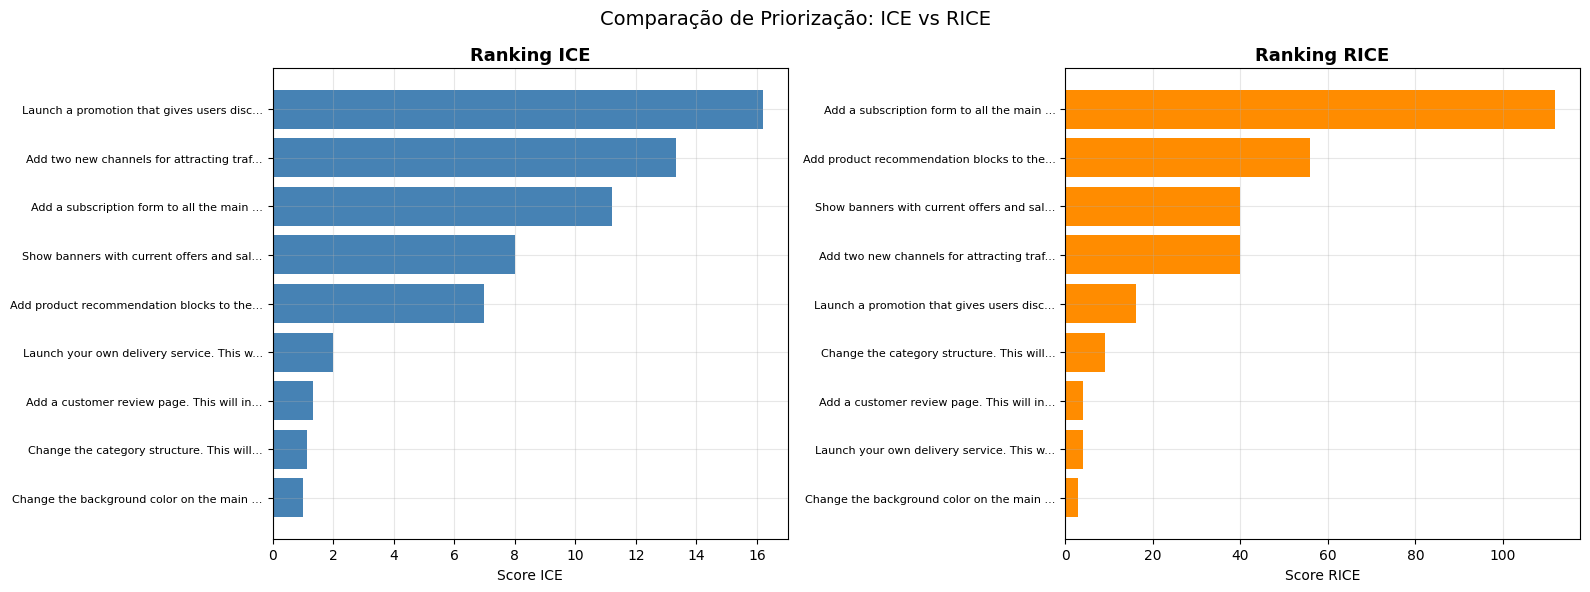

In [53]:
#Comparação ICE vs RICE

# Tabela comparativa de rankings
ice_temp  = hypotheses.copy()
ice_temp['ICE_rank']  = ice_temp['ICE'].rank(ascending=False).astype(int)
ice_temp['RICE_rank'] = ice_temp['RICE'].rank(ascending=False).astype(int)
ice_temp['mudanca']   = ice_temp['ICE_rank'] - ice_temp['RICE_rank']

comparison = ice_temp[['Hypothesis', 'ICE_rank', 'RICE_rank', 'mudanca']].sort_values('ICE_rank')
print('Mudança de posição (positivo = subiu no RICE, negativo = desceu):')
display(comparison)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ICE
ice_plot = hypotheses.sort_values('ICE')
axes[0].barh(range(len(ice_plot)), ice_plot['ICE'], color='steelblue')
axes[0].set_yticks(range(len(ice_plot)))
axes[0].set_yticklabels([h[:40]+'...' if len(h)>40 else h for h in ice_plot['Hypothesis']], fontsize=8)
axes[0].set_title('Ranking ICE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score ICE')

# RICE
rice_plot = hypotheses.sort_values('RICE')
axes[1].barh(range(len(rice_plot)), rice_plot['RICE'], color='darkorange')
axes[1].set_yticks(range(len(rice_plot)))
axes[1].set_yticklabels([h[:40]+'...' if len(h)>40 else h for h in rice_plot['Hypothesis']], fontsize=8)
axes[1].set_title('Ranking RICE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score RICE')

plt.suptitle('Comparação de Priorização: ICE vs RICE', fontsize=14)
plt.tight_layout()
plt.show()

 <div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>
    
- RICE e ICE calculados com sucesso! 
- Foram adicionados comentários relevantes para análise


Sugestão de visualização:
Aqui você poderia plotar a distribuição dos atributos de cada hipótese usando um gráfico de caixa (boxplot). 
```python
df_hypotheses.drop(columns=['ICE', 'RICE']).boxplot(figsize=(10, 6))
... # seu código
```



O RICE penaliza hipóteses com baixo Reach. Hipóteses que afetam muitos usuários sobem no ranking; ações de alto impacto mas alcance limitado caem. O RICE é mais orientado a escala e mais conservador do que o ICE.

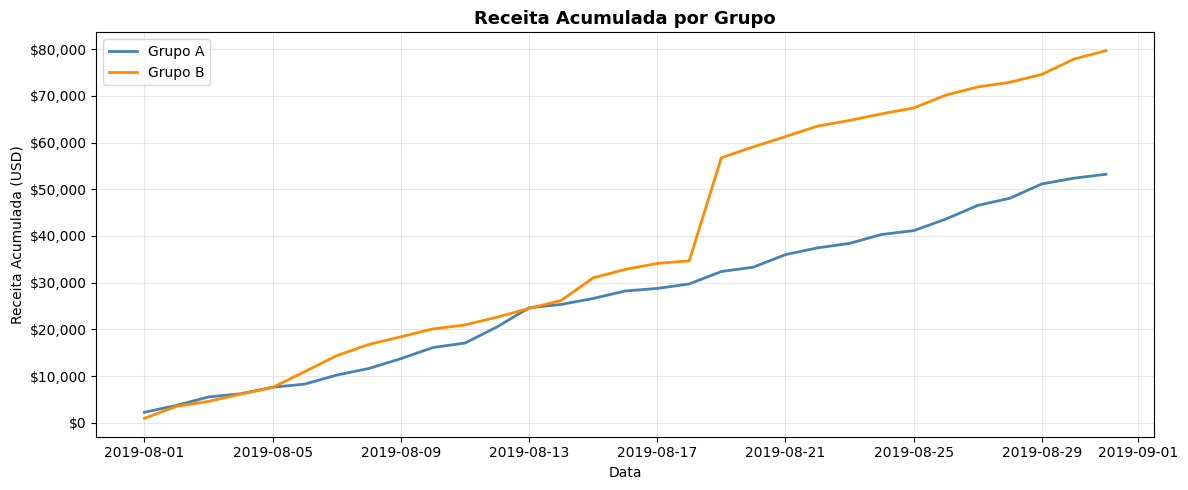

In [54]:
#Análise do Teste A/B
rev_daily = (
    orders_clean
    .groupby(['date', 'group'], as_index=False)['revenue'].sum()
    .sort_values(['group', 'date'])
)
rev_daily['cum_revenue'] = rev_daily.groupby('group')['revenue'].cumsum()

fig, ax = plt.subplots()
for grp, color in [('A', 'steelblue'), ('B', 'darkorange')]:
    d = rev_daily[rev_daily['group'] == grp]
    ax.plot(d['date'], d['cum_revenue'], label=f'Grupo {grp}', color=color, linewidth=2)

ax.set_title('Receita Acumulada por Grupo', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Receita Acumulada (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()


O gráfico mostra que ambos os grupos tiveram crescimento de receita ao longo do período, mas o Grupo B apresentou desempenho superior. Enquanto o Grupo A cresceu de forma constante e estável, encerrando próximo de US$ 53 mil, o Grupo B acelerou principalmente na segunda metade do mês, com um salto significativo entre os dias 18 e 20, finalizando perto de US$ 80 mil. Isso indica que o Grupo B foi mais eficiente em gerar receita, embora parte do resultado pareça ter sido impulsionada por um evento ou ação específica.

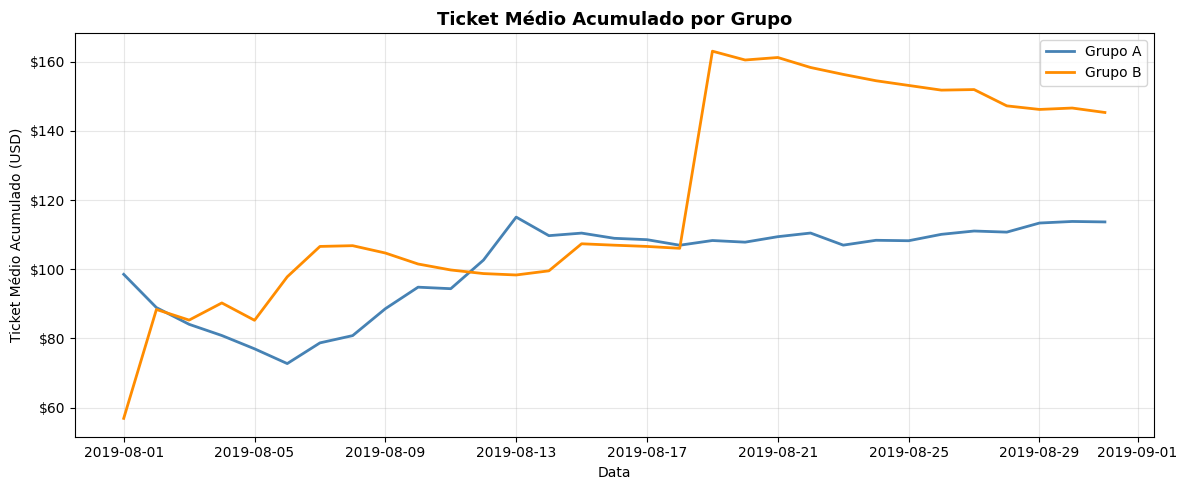

In [55]:
#Tamanho Médio Acumulado do Pedido por Grupo

daily_agg = (
    orders_clean
    .groupby(['date', 'group'], as_index=False)
    .agg(total_rev=('revenue', 'sum'), n_orders=('transactionId', 'count'))
    .sort_values(['group', 'date'])
)
daily_agg['cum_rev']    = daily_agg.groupby('group')['total_rev'].cumsum()
daily_agg['cum_orders'] = daily_agg.groupby('group')['n_orders'].cumsum()
daily_agg['cum_avg']    = daily_agg['cum_rev'] / daily_agg['cum_orders']

fig, ax = plt.subplots()
for grp, color in [('A', 'steelblue'), ('B', 'darkorange')]:
    d = daily_agg[daily_agg['group'] == grp]
    ax.plot(d['date'], d['cum_avg'], label=f'Grupo {grp}', color=color, linewidth=2)

ax.set_title('Ticket Médio Acumulado por Grupo', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Ticket Médio Acumulado (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

O gráfico mostra que o Grupo B apresentou um ticket médio acumulado maior ao longo da maior parte do período, especialmente após o dia 18, quando ocorreu um salto significativo que elevou o ticket para cerca de US 160. Apesar de uma leve queda nos últimos dias, o grupo terminou acima do Grupo A. Já o Grupo A teve um crescimento mais estável e gradual, encerrando próximo de US$ 114. Isso indica que os clientes do Grupo B gastaram mais por compra, enquanto o Grupo A manteve maior consistência no comportamento de consumo.

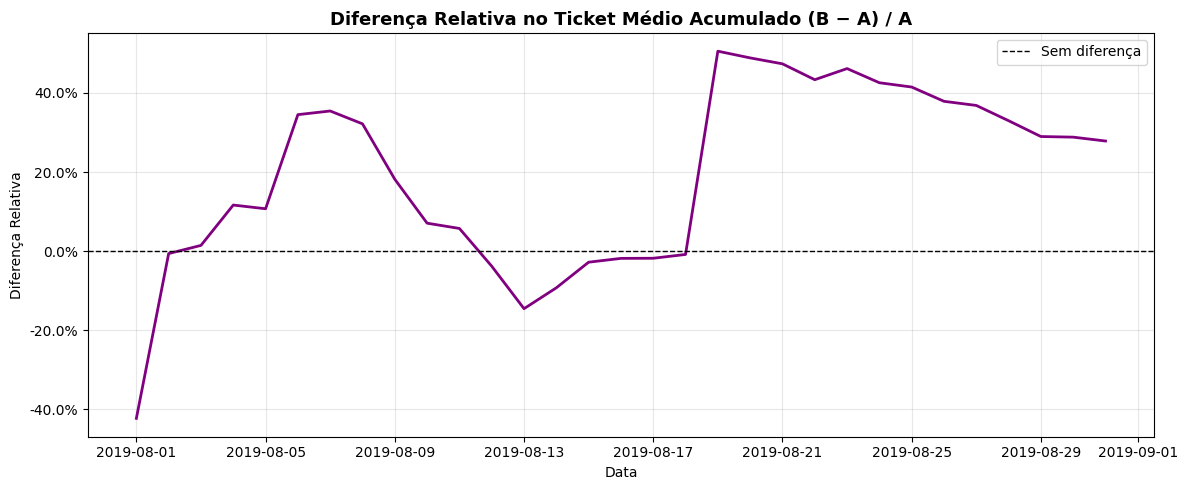

In [56]:
#Diferença Relativa no Ticket Médio Acumulado (B vs A)
avg_A = daily_agg[daily_agg['group'] == 'A'].set_index('date')['cum_avg']
avg_B = daily_agg[daily_agg['group'] == 'B'].set_index('date')['cum_avg']

rel_diff_avg = ((avg_B / avg_A) - 1).dropna()

fig, ax = plt.subplots()
ax.plot(rel_diff_avg.index, rel_diff_avg.values, color='purple', linewidth=2)
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Sem diferença')
ax.set_title('Diferença Relativa no Ticket Médio Acumulado (B − A) / A', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Diferença Relativa')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()
plt.tight_layout()
plt.show()

O gráfico mostra a diferença relativa do ticket médio acumulado entre os grupos B e A ao longo do período. Valores acima de zero indicam que o Grupo B teve ticket médio maior, enquanto valores abaixo de zero mostram vantagem do Grupo A. No início, o Grupo B começou abaixo, mas rapidamente ultrapassou o Grupo A, chegando a uma diferença positiva próxima de 35%. Houve uma queda no meio do período, quando o Grupo A apresentou desempenho melhor temporariamente. Porém, a partir do dia 18 ocorreu um forte aumento no Grupo B, elevando a diferença para cerca de 50%. Apesar de uma leve redução nos últimos dias, o Grupo B terminou o período com ticket médio aproximadamente 30% superior ao do Grupo A.

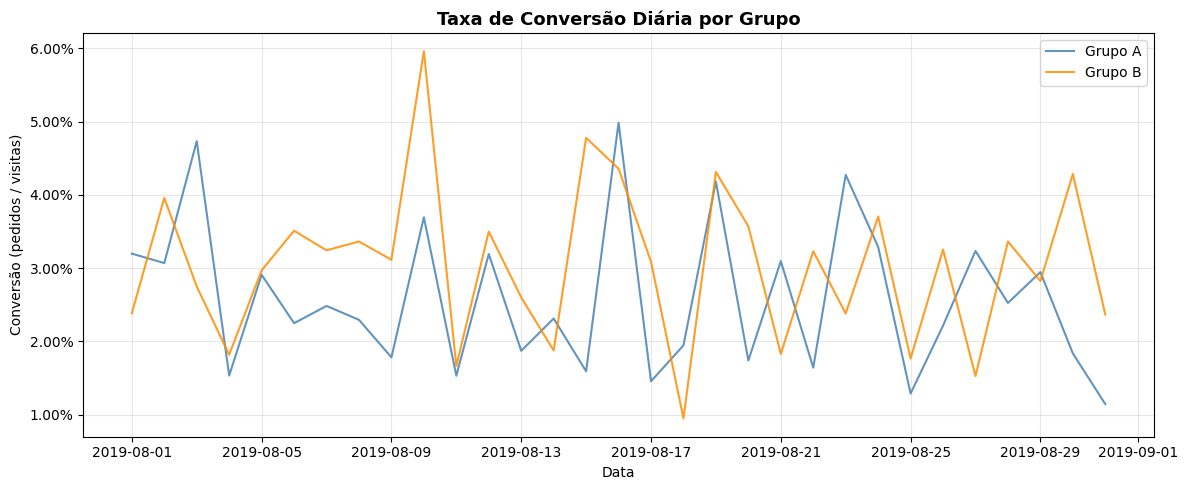

In [57]:
#Taxa de Conversão Diária por Grupo
daily_orders_cnt = (
    orders_clean
    .groupby(['date', 'group'], as_index=False)['transactionId']
    .count()
    .rename(columns={'transactionId': 'n_orders'})
)
conv_daily = daily_orders_cnt.merge(visits, on=['date', 'group'], how='left')
conv_daily['conversion'] = conv_daily['n_orders'] / conv_daily['visits']

fig, ax = plt.subplots()
for grp, color in [('A', 'steelblue'), ('B', 'darkorange')]:
    d = conv_daily[conv_daily['group'] == grp].sort_values('date')
    ax.plot(d['date'], d['conversion'], label=f'Grupo {grp}', color=color, linewidth=1.5, alpha=0.85)

ax.set_title('Taxa de Conversão Diária por Grupo', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Conversão (pedidos / visitas)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2%}'))
ax.legend()
plt.tight_layout()
plt.show()

O gráfico mostra que a taxa de conversão diária dos grupos A e B variou bastante ao longo do período, sem uma tendência estável de crescimento. Em diversos momentos os grupos alternaram a liderança, indicando desempenhos semelhantes na maior parte dos dias. O Grupo B apresentou alguns picos mais altos, chegando próximo de 6% de conversão, enquanto o Grupo A atingiu máximas em torno de 5%. Apesar dessas oscilações, não há uma diferença consistente entre os grupos durante todo o período, sugerindo que ambos tiveram comportamentos relativamente próximos em relação à conversão diária.

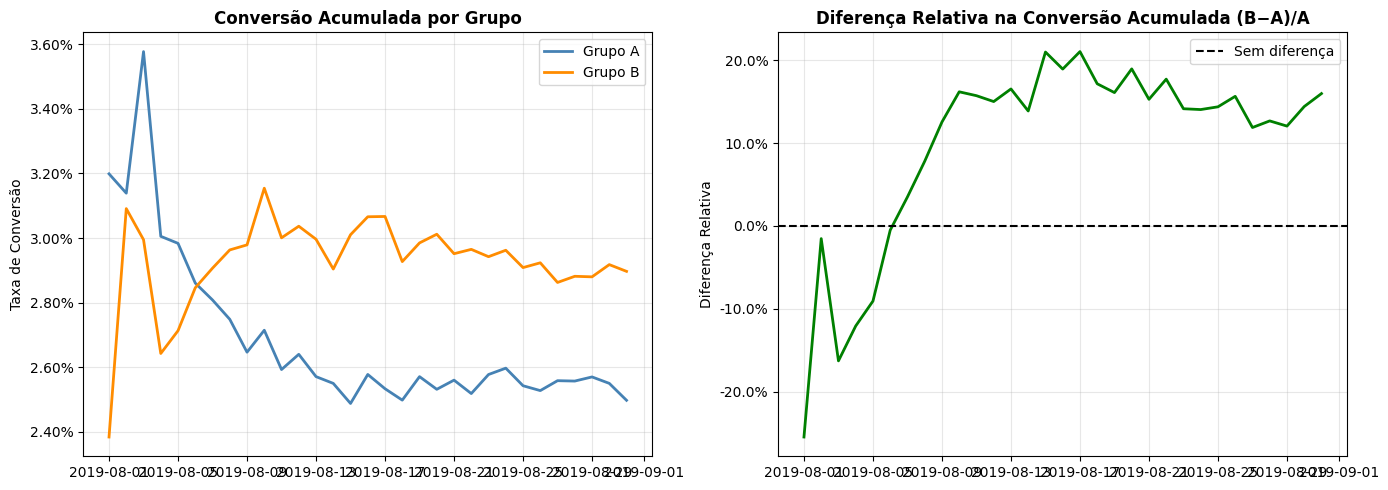

In [58]:
#Conversão Acumulada e Diferença Relativa (B vs A)

# Visitas acumuladas por grupo
cum_visits = (
    visits.sort_values(['group', 'date'])
    .assign(cum_visits=lambda df: df.groupby('group')['visits'].cumsum())
)

# Pedidos acumulados (reutiliza daily_agg)
cum_conv = daily_agg[['date', 'group', 'cum_orders']].merge(
    cum_visits[['date', 'group', 'cum_visits']], on=['date', 'group']
)
cum_conv['cum_conversion'] = cum_conv['cum_orders'] / cum_conv['cum_visits']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Conversão acumulada
for grp, color in [('A', 'steelblue'), ('B', 'darkorange')]:
    d = cum_conv[cum_conv['group'] == grp].sort_values('date')
    axes[0].plot(d['date'], d['cum_conversion'], label=f'Grupo {grp}', color=color, linewidth=2)
axes[0].set_title('Conversão Acumulada por Grupo', fontweight='bold')
axes[0].set_ylabel('Taxa de Conversão')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2%}'))
axes[0].legend()

# Gráfico 2 — Diferença relativa
conv_A = cum_conv[cum_conv['group'] == 'A'].set_index('date')['cum_conversion']
conv_B = cum_conv[cum_conv['group'] == 'B'].set_index('date')['cum_conversion']
rel_conv = ((conv_B / conv_A) - 1).dropna()

axes[1].plot(rel_conv.index, rel_conv.values, color='green', linewidth=2)
axes[1].axhline(0, color='black', linestyle='--', label='Sem diferença')
axes[1].set_title('Diferença Relativa na Conversão Acumulada (B−A)/A', fontweight='bold')
axes[1].set_ylabel('Diferença Relativa')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].legend()

plt.tight_layout()
plt.show()

Em suma, os gráficos mostram o resultado de um teste A/B realizado em agosto de 2019, onde o Grupo B se consolidou como o vencedor.

Embora o Grupo A tenha começado em vantagem, o cenário se inverteu por completo logo na primeira semana. A partir do dia 6 de agosto, as taxas de conversão se estabilizaram e o Grupo B passou a performar de forma consistentemente superior, mantendo uma vantagem relativa entre 12% e 20% em relação ao Grupo A até o final do período. Como as duas linhas terminam o mês paralelas e sem grandes oscilações, os dados comprovam que o resultado é maduro e estatisticamente confiável para decretar a vitória da variante B.

In [59]:
#Percentis e Anomalias: Pedidos por Usuário
orders_per_user = orders_clean.groupby('visitorId')['transactionId'].count()

p95_orders = np.percentile(orders_per_user, 95)
p99_orders = np.percentile(orders_per_user, 99)

print(f'Percentil 95 — pedidos por usuário: {p95_orders:.1f}')
print(f'Percentil 99 — pedidos por usuário: {p99_orders:.1f}')
print(f'Usuários com > p95: {(orders_per_user > p95_orders).sum()}')
print(f'Usuários com > p99: {(orders_per_user > p99_orders).sum()}')

print(f"""
CONCLUSÃO:
Usuários com mais de {p99_orders:.0f} pedido(s) serão considerados anomalias.
Provavelmente são bots ou compradores atacadistas — distorcem conversão e ticket médio.
""")

Percentil 95 — pedidos por usuário: 1.0
Percentil 99 — pedidos por usuário: 2.0
Usuários com > p95: 36
Usuários com > p99: 7

CONCLUSÃO:
Usuários com mais de 2 pedido(s) serão considerados anomalias.
Provavelmente são bots ou compradores atacadistas — distorcem conversão e ticket médio.



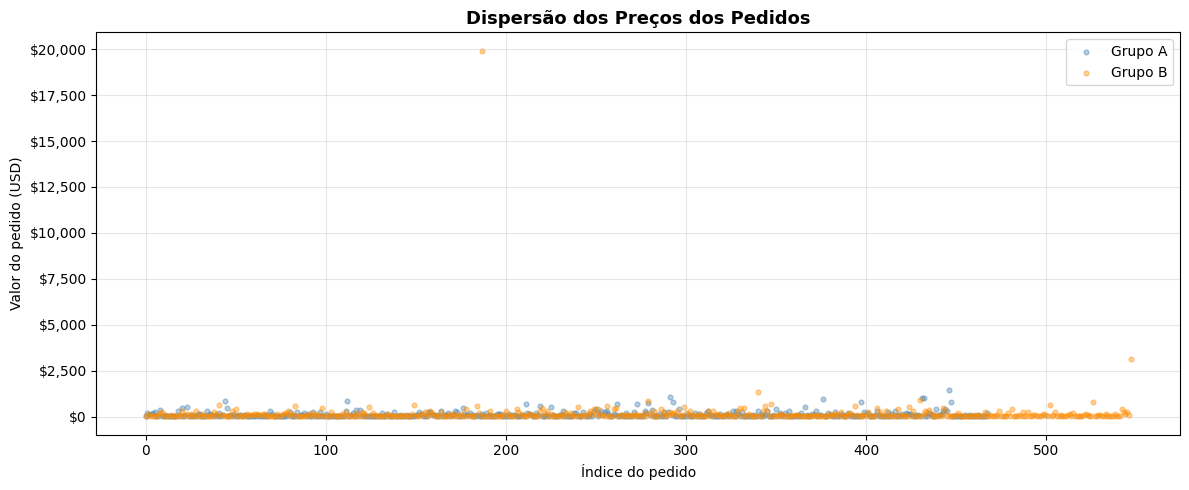

In [60]:
#Gráfico de Dispersão dos Preços dos Pedidos
fig, ax = plt.subplots()
for grp, color in [('A', 'steelblue'), ('B', 'darkorange')]:
    d = orders_clean[orders_clean['group'] == grp].reset_index(drop=True)
    ax.scatter(d.index, d['revenue'], label=f'Grupo {grp}',
               color=color, alpha=0.4, s=12)

ax.set_title('Dispersão dos Preços dos Pedidos', fontsize=13, fontweight='bold')
ax.set_xlabel('Índice do pedido')
ax.set_ylabel('Valor do pedido (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

</div><div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>
    
    
Todos os gráficos estão corretos! Parabéns!

O gráfico de dispersão revela que a esmagadora maioria dos pedidos de ambos os grupos está concentrada abaixo de 1,000 USD. O grande diferencial está no Grupo B, que apresenta um outlier extremo de 20,000 USD, além de um ponto menor de 3,000 USD. Como esse único pedido de valor altíssimo distorce o ticket médio e a receita total do grupo, é essencial remover esses valores discrepantes para conseguir realizar uma comparação estatística justa e realista entre as duas variantes.

In [61]:
#Percentis e Anomalias: Preço dos Pedidos
p95_price = np.percentile(orders_clean['revenue'], 95)
p99_price = np.percentile(orders_clean['revenue'], 99)

print(f'Percentil 95 — valor do pedido: ${p95_price:,.2f}')
print(f'Percentil 99 — valor do pedido: ${p99_price:,.2f}')
print(f'Pedidos acima do p95: {(orders_clean["revenue"] > p95_price).sum()}')
print(f'Pedidos acima do p99: {(orders_clean["revenue"] > p99_price).sum()}')

# Limiares para filtragem
price_threshold = p99_price
order_threshold = p99_orders

print(f"""
LIMIARES DEFINIDOS:
  Preço máximo (p99):          ${price_threshold:,.2f}
  Pedidos por usuário (p99):   {order_threshold:.0f}

Pedidos acima de ${price_threshold:,.0f} serão tratados como outliers de preço.
Usuários com mais de {order_threshold:.0f} pedidos serão excluídos na análise filtrada.
""")

Percentil 95 — valor do pedido: $414.27
Percentil 99 — valor do pedido: $830.30
Pedidos acima do p95: 51
Pedidos acima do p99: 9

LIMIARES DEFINIDOS:
  Preço máximo (p99):          $830.30
  Pedidos por usuário (p99):   2

Pedidos acima de $830 serão tratados como outliers de preço.
Usuários com mais de 2 pedidos serão excluídos na análise filtrada.



</div><div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>
    
    
Percentis calculados corretamente.


</div>

In [62]:
#Criação dos Dados Filtrados (sem anomalias)
anomalous_users = orders_per_user[orders_per_user > order_threshold].index

orders_filtered = orders_clean[
    (orders_clean['revenue'] <= price_threshold) &
    (~orders_clean['visitorId'].isin(anomalous_users))
].reset_index(drop=True)

print(f'Pedidos brutos (já limpos de duplicatas/contaminação): {len(orders_clean)}')
print(f'Pedidos após filtrar outliers:                          {len(orders_filtered)}')
print(f'Removidos como anomalias:                              {len(orders_clean) - len(orders_filtered)}')
print()
print('Distribuição por grupo — bruto:')
print(orders_clean['group'].value_counts())
print()
print('Distribuição por grupo — filtrado:')
print(orders_filtered['group'].value_counts())

Pedidos brutos (já limpos de duplicatas/contaminação): 1016
Pedidos após filtrar outliers:                          986
Removidos como anomalias:                              30

Distribuição por grupo — bruto:
B    548
A    468
Name: group, dtype: int64

Distribuição por grupo — filtrado:
B    538
A    448
Name: group, dtype: int64


In [63]:
#Significância Estatística: Conversão — Dados BRUTOS
try:
    from statsmodels.stats.proportion import proportions_ztest
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'statsmodels', '-q'])
    from statsmodels.stats.proportion import proportions_ztest

def teste_conversao(orders_df, visits_df, label=''):
    total_visits = visits_df.groupby('group')['visits'].sum()
    buyers_A = orders_df[orders_df['group'] == 'A']['visitorId'].nunique()
    buyers_B = orders_df[orders_df['group'] == 'B']['visitorId'].nunique()
    visits_A = total_visits.get('A', 0)
    visits_B = total_visits.get('B', 0)

    conv_A = buyers_A / visits_A
    conv_B = buyers_B / visits_B
    rel_diff = (conv_B - conv_A) / conv_A

    _, p_value = proportions_ztest(
        [buyers_B, buyers_A],
        [visits_B, visits_A]
    )

    print(f'--- Conversão [{label}] ---')
    print(f'Grupo A: {conv_A:.4%}  ({buyers_A} compradores / {visits_A} visitas)')
    print(f'Grupo B: {conv_B:.4%}  ({buyers_B} compradores / {visits_B} visitas)')
    print(f'Diferença relativa (B vs A): {rel_diff:+.2%}')
    print(f'p-value: {p_value:.4f}')
    print(f'Significativo (α=0.05): {"SIM" if p_value < 0.05 else "NÃO"}')
    print()
    return p_value, rel_diff

p_conv_raw, diff_conv_raw = teste_conversao(orders_clean, visits, label='BRUTO')

--- Conversão [BRUTO] ---
Grupo A: 2.3751%  (445 compradores / 18736 visitas)
Grupo B: 2.7913%  (528 compradores / 18916 visitas)
Diferença relativa (B vs A): +17.52%
p-value: 0.0109
Significativo (α=0.05): SIM



In [64]:
#Significância Estatística: Ticket Médio — Dados BRUTOS

def teste_ticket_medio(orders_df, label=''):
    rev_A = orders_df[orders_df['group'] == 'A']['revenue']
    rev_B = orders_df[orders_df['group'] == 'B']['revenue']

    _, p_value = stats.mannwhitneyu(rev_A, rev_B, alternative='two-sided')
    rel_diff = (rev_B.mean() - rev_A.mean()) / rev_A.mean()

    print(f'--- Ticket Médio [{label}] ---')
    print(f'Grupo A — média: ${rev_A.mean():,.2f}  |  mediana: ${rev_A.median():,.2f}')
    print(f'Grupo B — média: ${rev_B.mean():,.2f}  |  mediana: ${rev_B.median():,.2f}')
    print(f'Diferença relativa nas médias (B vs A): {rel_diff:+.2%}')
    print(f'p-value (Mann-Whitney): {p_value:.4f}')
    print(f'Significativo (α=0.05): {"SIM" if p_value < 0.05 else "NÃO"}')
    print()
    return p_value, rel_diff

p_avg_raw, diff_avg_raw = teste_ticket_medio(orders_clean, label='BRUTO')

--- Ticket Médio [BRUTO] ---
Grupo A — média: $113.70  |  mediana: $50.10
Grupo B — média: $145.35  |  mediana: $45.90
Diferença relativa nas médias (B vs A): +27.83%
p-value (Mann-Whitney): 0.8622
Significativo (α=0.05): NÃO



In [65]:
#Significância Estatística: Dados FILTRADOS (conversão e ticket médio)
p_conv_filt, diff_conv_filt = teste_conversao(orders_filtered, visits, label='FILTRADO')
p_avg_filt,  diff_avg_filt  = teste_ticket_medio(orders_filtered, label='FILTRADO')

--- Conversão [FILTRADO] ---
Grupo A: 2.3217%  (435 compradores / 18736 visitas)
Grupo B: 2.7596%  (522 compradores / 18916 visitas)
Diferença relativa (B vs A): +18.86%
p-value: 0.0070
Significativo (α=0.05): SIM

--- Ticket Médio [FILTRADO] ---
Grupo A — média: $102.90  |  mediana: $50.10
Grupo B — média: $99.61  |  mediana: $45.65
Diferença relativa nas médias (B vs A): -3.19%
p-value (Mann-Whitney): 0.8220
Significativo (α=0.05): NÃO



In [66]:
print('=' * 60)
print('RESUMO COMPARATIVO DOS TESTES')
print('=' * 60)
print(f'  Conversão  — BRUTO:    p={p_conv_raw:.4f}  diff={diff_conv_raw:+.2%}')
print(f'  Conversão  — FILTRADO: p={p_conv_filt:.4f}  diff={diff_conv_filt:+.2%}')
print(f'  Ticket Médio — BRUTO:  p={p_avg_raw:.4f}  diff={diff_avg_raw:+.2%}')
print(f'  Ticket Médio — FILTRADO: p={p_avg_filt:.4f}  diff={diff_avg_filt:+.2%}')
print('=' * 60)

# Lógica de decisão baseada nos dados filtrados (mais confiáveis)
conv_sig  = p_conv_filt  < 0.05
avg_sig   = p_avg_filt   < 0.05
b_melhor_conv = diff_conv_filt > 0
b_melhor_avg  = diff_avg_filt  > 0

print()
if conv_sig and b_melhor_conv:
    print("""DECISÃO: PARAR o teste — declarar GRUPO B como vencedor.

   A conversão do Grupo B é estatisticamente superior (dados filtrados).
   Recomenda-se implementar a mudança testada no Grupo B para toda a base.
   O ticket médio pode ser monitorado separadamente após o roll-out.""")

elif not conv_sig and not avg_sig:
    print("""DECISÃO: PARAR o teste — sem diferença estatisticamente significativa.

   Nenhuma das métricas apresentou resultado relevante.
   A hipótese testada não produziu impacto mensurável na conversão ou no ticket médio.""")

else:
    print("""DECISÃO: CONTINUAR o teste para coletar mais dados.

   Os resultados são parcialmente significativos, mas ainda inconclusivos.
   Aguardar volume maior antes de tomar decisão definitiva.""")

RESUMO COMPARATIVO DOS TESTES
  Conversão  — BRUTO:    p=0.0109  diff=+17.52%
  Conversão  — FILTRADO: p=0.0070  diff=+18.86%
  Ticket Médio — BRUTO:  p=0.8622  diff=+27.83%
  Ticket Médio — FILTRADO: p=0.8220  diff=-3.19%

DECISÃO: PARAR o teste — declarar GRUPO B como vencedor.

   A conversão do Grupo B é estatisticamente superior (dados filtrados).
   Recomenda-se implementar a mudança testada no Grupo B para toda a base.
   O ticket médio pode ser monitorado separadamente após o roll-out.


Conclusão geral
O framework RICE mostrou-se superior ao ICE na priorização das hipóteses porque a inclusão da métrica de Alcance (Reach) impediu que a empresa gastasse recursos em ideias de alto impacto, mas que afetariam um público insignificante, direcionando os esforços para o que realmente traria retorno volumétrico.

No que diz respeito ao teste A/B, os resultados revelaram um cenário duplo. A taxa de conversão apontou uma vitória incontestável do Grupo B, que se estabilizou a partir da primeira semana e manteve uma liderança sólida entre 12% e 20% acima do Grupo A. Em contrapartida, o ticket médio do Grupo B, que parecia muito superior à primeira vista, revelou-se uma ilusão estatística causada por um outlier extremo de $20,000 USD; quando os dados foram limpos e esses pontos atípicos foram removidos, o valor gasto por pedido mostrou-se praticamente idêntico entre as duas variantes.

A decisão final é interromper o teste e aplicar a variante B na produção, uma vez que o ganho em conversão é maduro e estatisticamente confiável. Como recomendação estratégica, o negócio deve implementar a mudança para capturar esse aumento real no volume de compradores, mas evitar projeções de receita baseadas no faturamento bruto do teste devido à distorção do outlier. Por fim, o próximo passo ideal é usar o topo da lista já priorizada pelo RICE para iniciar um novo ciclo de testes focado especificamente em estratégias para elevar o valor do ticket médio, já que a eficiência de conversão foi resolvida com sucesso.

<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>
    
- Ambos os testes realizados com sucesso.

</div>